# Behavior Heterogeneity Analysis

This notebook examines whether students use the AI assistant in systematically different ways, and whether those usage profiles are associated with later exam outcomes. It starts from problem-level chat annotations, converts each student-problem pair into behavior features, aggregates those features to one student-level profile, and then compares exam scores across profiles.

The key output is a set of student-level behavior categories that separate passive answer use from active attempts, verification, and correction. Those categories are then used to summarize score differences across learning behaviors.


## Setup

This block imports shared utilities and sets the repository and figure paths. The notebook keeps classification and aggregation logic visible, while helper functions handle low-level JSON parsing, statistical tests, and publication-style plotting.


In [1]:
from pathlib import Path
import sys
import warnings
import matplotlib.pyplot as plt

# Suppress display-only warnings so notebook output stays focused on the analysis results.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
# Clear figures left open by previous interactive runs before saving new PDFs.
plt.close("all")


def _find_repo_root():
    """Find the repository root from either Jupyter or the test runner."""
    # Jupyter kernels often start inside the repository, but not always at root.
    # We walk upward until we find the project markers used by this repository.
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "analyze").exists():
            return candidate
    raise RuntimeError("Could not locate repository root.")


def _data_path(*candidates):
    """Return the first existing path across current and legacy data layouts."""
    # Some analysis artifacts were produced in the original EduAnalyze layout.
    # Keeping these fallbacks makes the notebook runnable in both locations.
    for candidate in candidates:
        path = Path(candidate)
        if not path.is_absolute():
            path = REPO_ROOT / path
        if path.exists():
            return path
    return REPO_ROOT / candidates[0]


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Figures are written to the repository by default. Tests override this path.
FIGURES_DIR = REPO_ROOT / "figures"
SHOW_FIGURES = True
print("Repository:", ".")
print("Figures:", "figures")


Repository: .
Figures: figures


In [2]:
from collections import Counter
from pathlib import Path

import pandas as pd

import analyze.behavior.a1 as behavior
import analyze.stats.tests as stats_tests
import analyze.visualization.behavior_plots as behavior_plots

# Plot functions receive explicit paths and the SHOW_FIGURES flag below, so tests
# can run the notebook without opening interactive windows.
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Python Course: Construct Student Behavior Profiles

This block converts A1 Python chat annotations into one behavior profile per experimental student. For each student, it builds an ordered list of annotated chats for every A1 problem, adds problems attempted without chat, computes problem-level behavior features, and aggregates those features into a student-level category.

The resulting counts show how many students fall into each profile, including students who completed work without using chat.


In [3]:
# Input files for Python A1 behavior analysis.
# labels: annotated chat behavior; scores: randomized group and exam score;
# details: problem attempts, including work done without chat.
PY_LABELS_PATH = _data_path(
    "data/annotation/a1_chat_labels.json",
)
PY_SCORES_PATH = REPO_ROOT / "data/annotation/python_scores.json"
PY_DETAILS_PATH = REPO_ROOT / "data/annotation/python_details.json"
EXCLUDE_USERS_PATH = REPO_ROOT / "data/processed/exclude_user.csv"

py_labels = behavior.load_json(PY_LABELS_PATH)
py_scores = behavior.load_json(PY_SCORES_PATH)
py_details = behavior.load_json(PY_DETAILS_PATH)
excluded_users = behavior.load_exclude_users(EXCLUDE_USERS_PATH)

# Infer the A1 Python problem IDs from the annotation keys instead of hard-coding
# them. This reduces the chance of silently omitting a labeled problem.
py_target_problems = behavior.infer_target_problems_from_labels(
    py_labels,
    stage="a1",
    problem_prefix="py_",
)
print("Python target problems:", py_target_problems)

# Build user -> problem -> ordered chat labels for experimental users.
# The policy "attempted_or_chatted" includes a problem when either evidence is present.
py_problem_chats = behavior.build_user_problem_chats(
    py_labels,
    py_scores,
    py_details,
    group="Experiment",
    stage="a1",
    problem_prefix="py_",
    drop_unk_ask=True,
    target_problems=py_target_problems,
    problem_denom_policy="attempted_or_chatted",
    excluded_users=excluded_users,
)

# Mark problems where the student submitted or attempted work without any chat.
# These observations are needed to represent unaided behavior correctly.
py_attempted_without_chat = behavior.build_user_problem_attempted_map(py_problem_chats, py_details)

# Aggregate from problem-level behavior features to one student-level profile.
# Thresholds encode the profile definitions: active trial requires attempted-first
# behavior; rote adoption requires a high copy-like answer-use rate.
py_features_by_user = behavior.compute_all_user_features(
    py_problem_chats,
    py_attempted_without_chat,
    py_scores,
    tried_threshold=0.25,
    copy_first_threshold=0.75,
    precedence=("no_chat", "ask_then_explain", "try_then_ask", "mindless_copy", "other"),
    nochat_tried_if_attempted=True,
)

py_features = list(py_features_by_user.values())

# Convert internal classifier codes to canonical behavior labels immediately after classification.
# Downstream tables, summaries, and plots never use the internal codes.
behavior.use_canonical_behavior_labels(py_features, course="python")

print("Python students:", len(py_features))
print("Python behavior counts:", dict(Counter(f.category for f in py_features)))


Python target problems: ['py_hw1/p1', 'py_hw1/p2', 'py_hw1/p3', 'py_hw1/p4', 'py_hw1/p5', 'py_hw1/p6', 'py_hw1/p7', 'py_hw1/p8']
Python students: 54
Python behavior counts: {'Rote-Adoption': 28, 'Active-Trial': 16, 'Unaided': 5, 'Verification': 5}


## Python Course: Inspect the Student-Level Table

This block displays the intermediate analysis table before plotting. Each row is one experimental student, with chat counts, attempted-problem counts, behavior rates, assigned profile, and exam score.

The summary table gives a quick check of category sizes, average exam scores, attempted-first behavior, and copy-like answer use.


In [4]:
# Convert dataclass-like feature objects into a readable dataframe.
# feature.category has already been converted to the canonical behavior labels.
py_profile_df = pd.DataFrame(behavior.user_features_to_rows(py_features))
py_profile_df["category"] = pd.Categorical(
    py_profile_df["category"],
    categories=behavior.PY_BEHAVIOR_ORDER,
    ordered=True,
)

# Display the columns that directly explain profile assignment and outcome analysis.
py_profile_df[[
    "user_id", "category", "n_chats", "n_problems", "tried_rate(problem)",
    "mindless_copy_rate(problem)", "any_answer_copy_rate(problem)", "HW2",
]].head()


,user_id,category,n_chats,n_problems,tried_rate(problem),mindless_copy_rate(problem),any_answer_copy_rate(problem),HW2
0,llm4edu-8Fmeb5M22jCUSuhPyXLv,Rote-Adoption,9,8,0.125,0.875,1.0,10.142857
1,llm4edu-GDACjOmc_9uW36rNK65_,Active-Trial,9,8,0.250,0.750,1.0,8.000000
2,llm4edu-LhuVtEqKiO8d2Lxf_Q9Y,Unaided,0,2,1.000,0.000,0.0,3.000000
3,llm4edu-YBPyVD2KveOArDRfV@sc,Rote-Adoption,10,8,0.000,1.000,1.0,11.000000
4,llm4edu-backup-pygpt-hBpu9JrFUS_nQ5An_W@j,Rote-Adoption,9,8,0.000,1.000,1.0,6.000000


In [5]:
# Summarize behavior profiles before looking at individual comparisons.
# This table checks whether category sizes and mean scores are plausible.
py_summary = (
    py_profile_df
    .groupby("category", dropna=False, observed=True, sort=False)
    .agg(
        n=("user_id", "count"),
        mean_hw2=("HW2", "mean"),
        median_hw2=("HW2", "median"),
        mean_tried_rate=("tried_rate(problem)", "mean"),
        mean_copy_rate=("mindless_copy_rate(problem)", "mean"),
    )
    .round(3)
)
py_summary


,n,mean_hw2,median_hw2,mean_tried_rate,mean_copy_rate
category,,,,,
Rote-Adoption,28,2.938,1.500,0.049,0.951
Active-Trial,16,6.548,6.500,0.523,0.477
Unaided,5,1.833,2.333,0.800,0.000
Verification,5,9.833,6.857,0.336,0.693


## Python Course: Compare Exam Scores by Profile

This block compares control students with experimental students grouped by behavior profile. The score vectors are constructed explicitly in the notebook, then passed to shared statistical and plotting helpers.

The printed statistics and saved figure summarize whether each behavior profile is associated with lower or higher exam scores relative to the control distribution.



Control vs Experiment (behavior groups) hypothesis tests (raw p-values):
  Control: n=27 mean=4.473 median=3.000
  Unaided: n=5 mean=1.833 median=2.333
  Rote-Adoption: n=28 mean=2.938 median=1.500
  Active-Trial: n=16 mean=6.548 median=6.500
  Verification: n=5 mean=9.833 median=6.857

  Kruskal–Wallis across groups: H=19.0797, p=0.000758095 (k=5)

  Pairwise Brunner–Munzel vs Control (one-sided where specified):
group	n_ctrl	n_grp	alt	stat	p_raw	p_bh
Unaided	27	5	less	1.9445	0.0431911	0.0431911
Rote-Adoption	27	28	less	2.0081	0.0250295	0.0333726
Active-Trial	27	16	greater	-2.2656	0.0146029	0.0292057
Verification	27	5	greater	-3.1908	0.00506079	0.0202432
Saved figure: a1_hw2_control_vs_exp_behavior.pdf


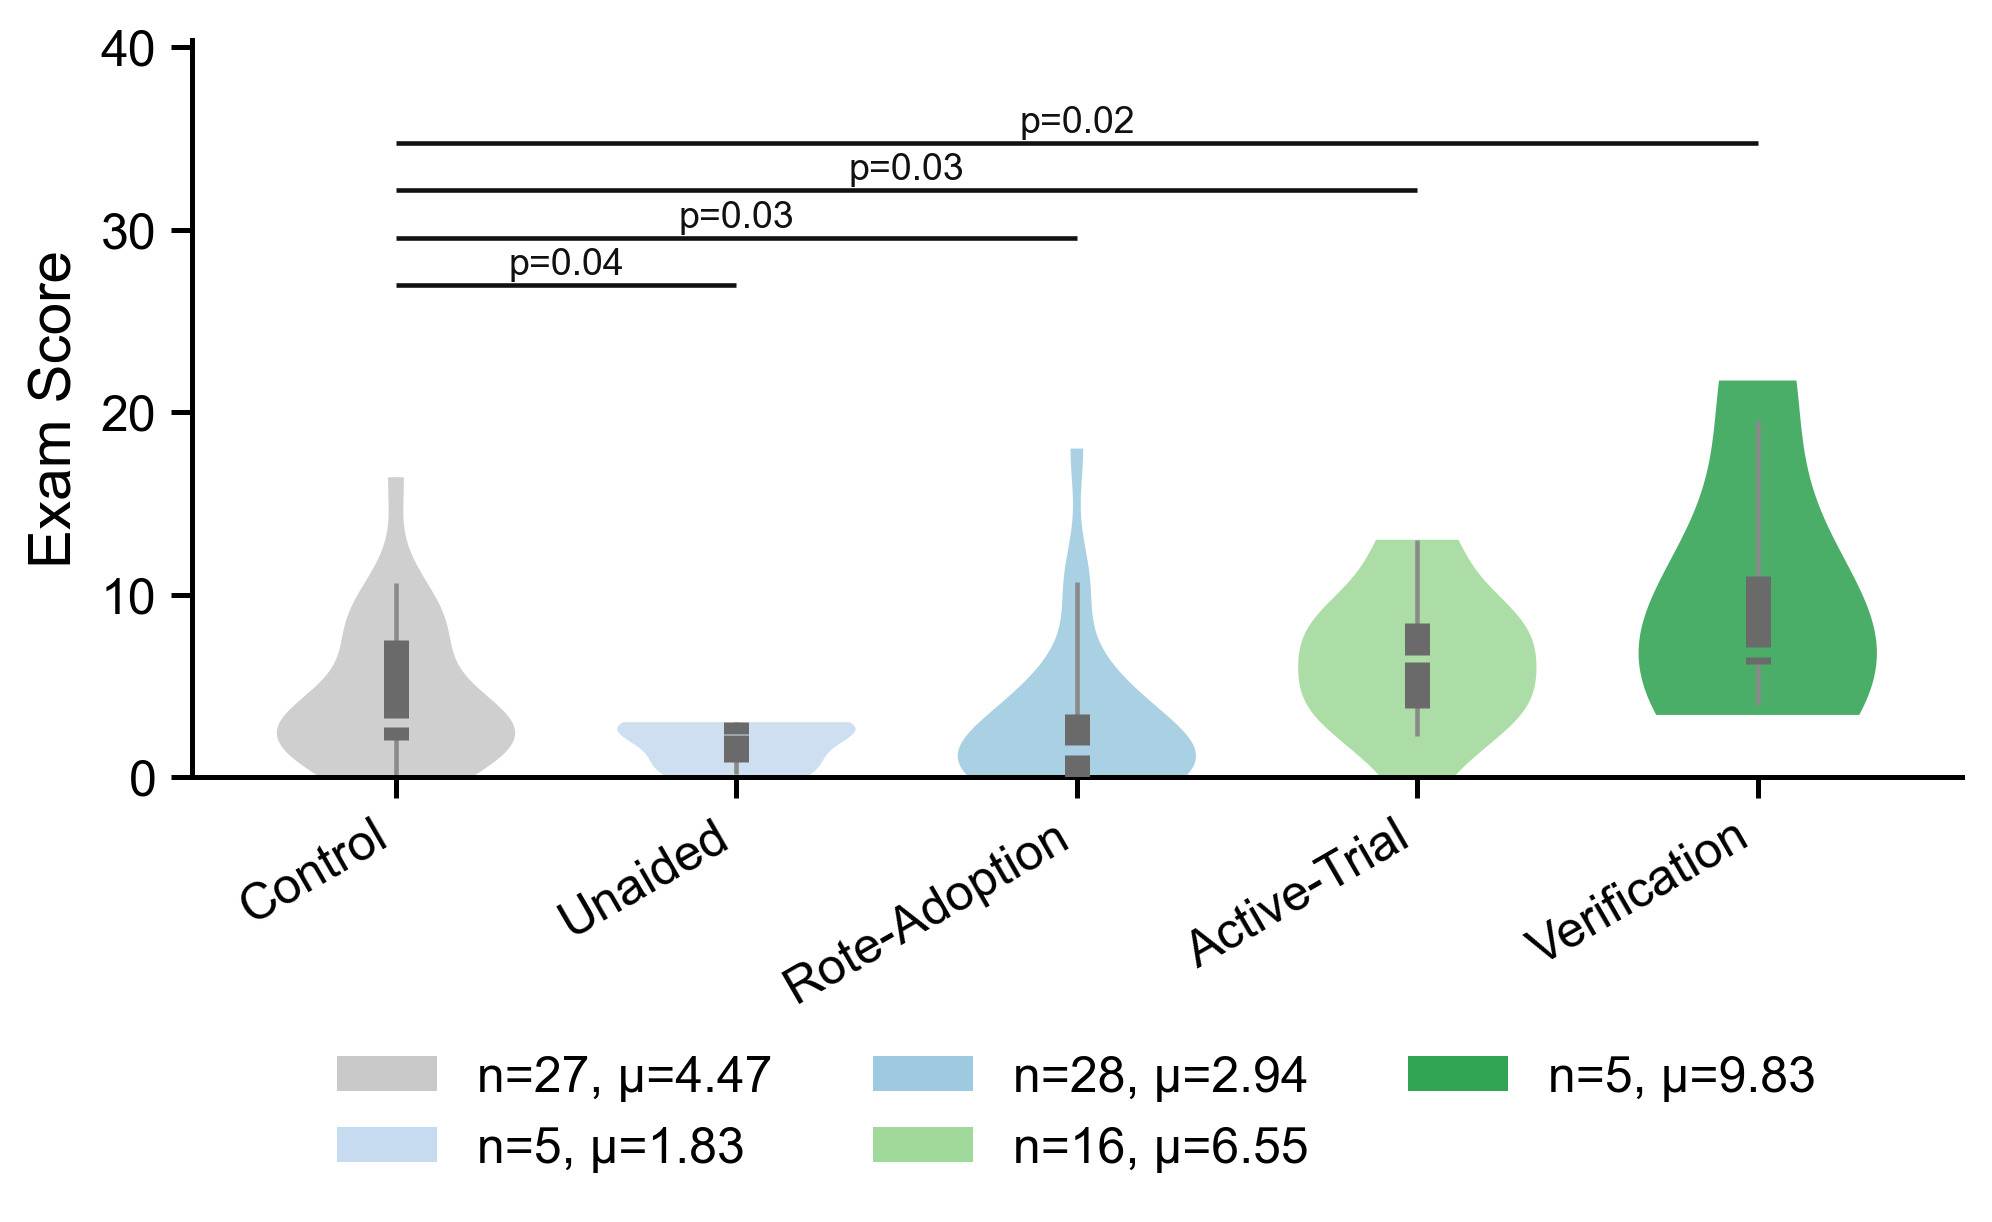

In [6]:
# Control group scores provide the no-assistant comparison distribution.
control_hw2_py = [
    behavior.safe_float(record.get("HW2"))
    for uid, record in py_scores.items()
    if isinstance(record, dict)
    and record.get("group") == "Control"
    and uid not in excluded_users
]
control_hw2_py = [x for x in control_hw2_py if x is not None]

# Use the already-mapped dataframe so score vectors have the same labels as the summaries.
py_scores_by_behavior = {
    label: py_profile_df.loc[py_profile_df["category"] == label, "HW2"].dropna().astype(float).tolist()
    for label in behavior.PY_BEHAVIOR_ORDER
}
py_scores_by_behavior = {k: v for k, v in py_scores_by_behavior.items() if v}

# One-sided directions follow the substantive hypothesis for each profile:
# passive profiles are expected to underperform, active/verification profiles to outperform.
stats_tests.print_control_vs_exp_tests(
    control_hw2=control_hw2_py,
    exp_hw2_by_behavior=py_scores_by_behavior,
    direction_by_group={
        "Unaided": "less",
        "Rote-Adoption": "less",
        "Active-Trial": "greater",
        "Verification": "greater",
    },
)

behavior_plots.plot_control_vs_exp_behaviors_hw2(
    control_hw2=control_hw2_py,
    exp_hw2_by_behavior=py_scores_by_behavior,
    exp_label_to_color={"Active-Trial": "#a1d99b", "Verification": "#31a354"},
    out_pdf=FIGURES_DIR / "a1_hw2_control_vs_exp_behavior.pdf",
    show=SHOW_FIGURES,
    direction_by_group={
        "Unaided": "less",
        "Rote-Adoption": "less",
        "Active-Trial": "greater",
        "Verification": "greater",
    },
)


## Game Theory Course: Construct Math-Specific Profiles

This block repeats the profile construction for Game Theory. The workflow is parallel to Python, but Game Theory annotations include blank-level correctness, which makes it possible to identify verification and error-correction behavior more directly.

The resulting table shows how many students fall into unaided, rote-adoption, active-trial, verification, and error-correction patterns.


In [7]:
# Reuse the same label file; math labels are selected by the math_ problem prefix.
MATH_LABELS_PATH = PY_LABELS_PATH
MATH_SCORES_PATH = _data_path(
    "data/llm/math_score_reviews_with_answers.json",
    "data/annotation/math_score_reviews_with_answers.json",
)
VALID_USERS_PATH = REPO_ROOT / "data/processed/validuser_merged.csv"

math_labels = behavior.load_json(MATH_LABELS_PATH)
math_raw = behavior.load_json(MATH_SCORES_PATH)
math_group_map = behavior.load_math_group_map(VALID_USERS_PATH)
math_scores = behavior.build_math_scores(group_map=math_group_map, excluded_users=excluded_users)

# Infer the four Game Theory A1 problems from labels.
math_target_problems = behavior.infer_target_problems_from_labels(
    math_labels,
    stage="a1",
    problem_prefix="math_",
)
print("Game Theory target problems:", math_target_problems)

# Build ordered math chats, keeping blank-level correctness metadata in each label.
math_problem_chats = behavior.build_user_problem_chats_math(
    math_labels,
    math_scores,
    math_raw,
    group="Experiment",
    stage="a1",
    problem_prefix="math_",
    drop_unk_ask=True,
    target_problems=math_target_problems,
    problem_denom_policy="attempted_or_chatted",
    excluded_users=excluded_users,
)
math_attempted_without_chat = behavior.build_user_problem_attempted_map_math(math_problem_chats, math_raw)

# Math profile precedence gives explicit verification/correction signals priority
# over more general attempted-first or copy-like categories.
math_features_by_user = behavior.compute_all_user_features_math(
    math_problem_chats,
    math_attempted_without_chat,
    math_scores,
    tried_threshold=0.5,
    copy_first_threshold=0.5,
    precedence=(
        "no_chat", "challenge_wrong", "fix_after_wrong",
        "ask_then_explain", "try_then_ask", "mindless_copy", "other",
    ),
    nochat_tried_if_attempted=True,
)

math_features = list(math_features_by_user.values())

# Convert internal math classifier codes to canonical behavior labels immediately.
# Both challenge_wrong and ask_then_explain are normalized to Verification here.
behavior.use_canonical_behavior_labels(math_features, course="math")

print("Game Theory students:", len(math_features))
print("Game Theory behavior counts:", dict(Counter(f.category for f in math_features)))


Game Theory target problems: ['math_hw1/p1', 'math_hw1/p2', 'math_hw1/p3', 'math_hw1/p4']
Game Theory students: 158
Game Theory behavior counts: {'Unaided': 33, 'Active-Trial': 47, 'Error-Correction': 24, 'Verification': 7, 'Rote-Adoption': 47}


In [8]:
# Inspect the Game Theory student-level table using the same summary structure.
# feature.category has already been converted to the canonical behavior labels.
math_profile_df = pd.DataFrame(behavior.user_features_to_rows_math(math_features))
math_profile_df["category"] = pd.Categorical(
    math_profile_df["category"],
    categories=behavior.MATH_BEHAVIOR_ORDER,
    ordered=True,
)

math_summary = (
    math_profile_df
    .groupby("category", dropna=False, observed=True, sort=False)
    .agg(
        n=("user_id", "count"),
        mean_hw2=("HW2", "mean"),
        median_hw2=("HW2", "median"),
        mean_tried_rate=("tried_rate(problem)", "mean"),
        mean_copy_rate=("mindless_copy_rate(problem)", "mean"),
    )
    .round(3)
)
math_summary


,n,mean_hw2,median_hw2,mean_tried_rate,mean_copy_rate
category,,,,,
Unaided,33,4.920,4.375,1.000,0.000
Active-Trial,47,5.858,5.250,0.725,0.239
Error-Correction,24,6.526,7.125,0.240,0.562
Verification,7,9.857,10.000,0.310,0.583
Rote-Adoption,47,4.394,2.688,0.078,0.911


## Cross-Course Composition and Game Theory Score Comparison

This block generates the cross-course behavior composition chart and the Game Theory outcome comparison. It defines small problem-feature adapters for the composition chart, then collapses math-specific profile codes into the broader labels used for score comparison.

The composition chart describes behavior at the student-problem level, while the score comparison uses one profile per student. Keeping both transformations visible clarifies the unit of analysis.


[Heterogeneity] Saved twin-panel: a1_behavior_heterogeneity_twin_python_game_theory.pdf


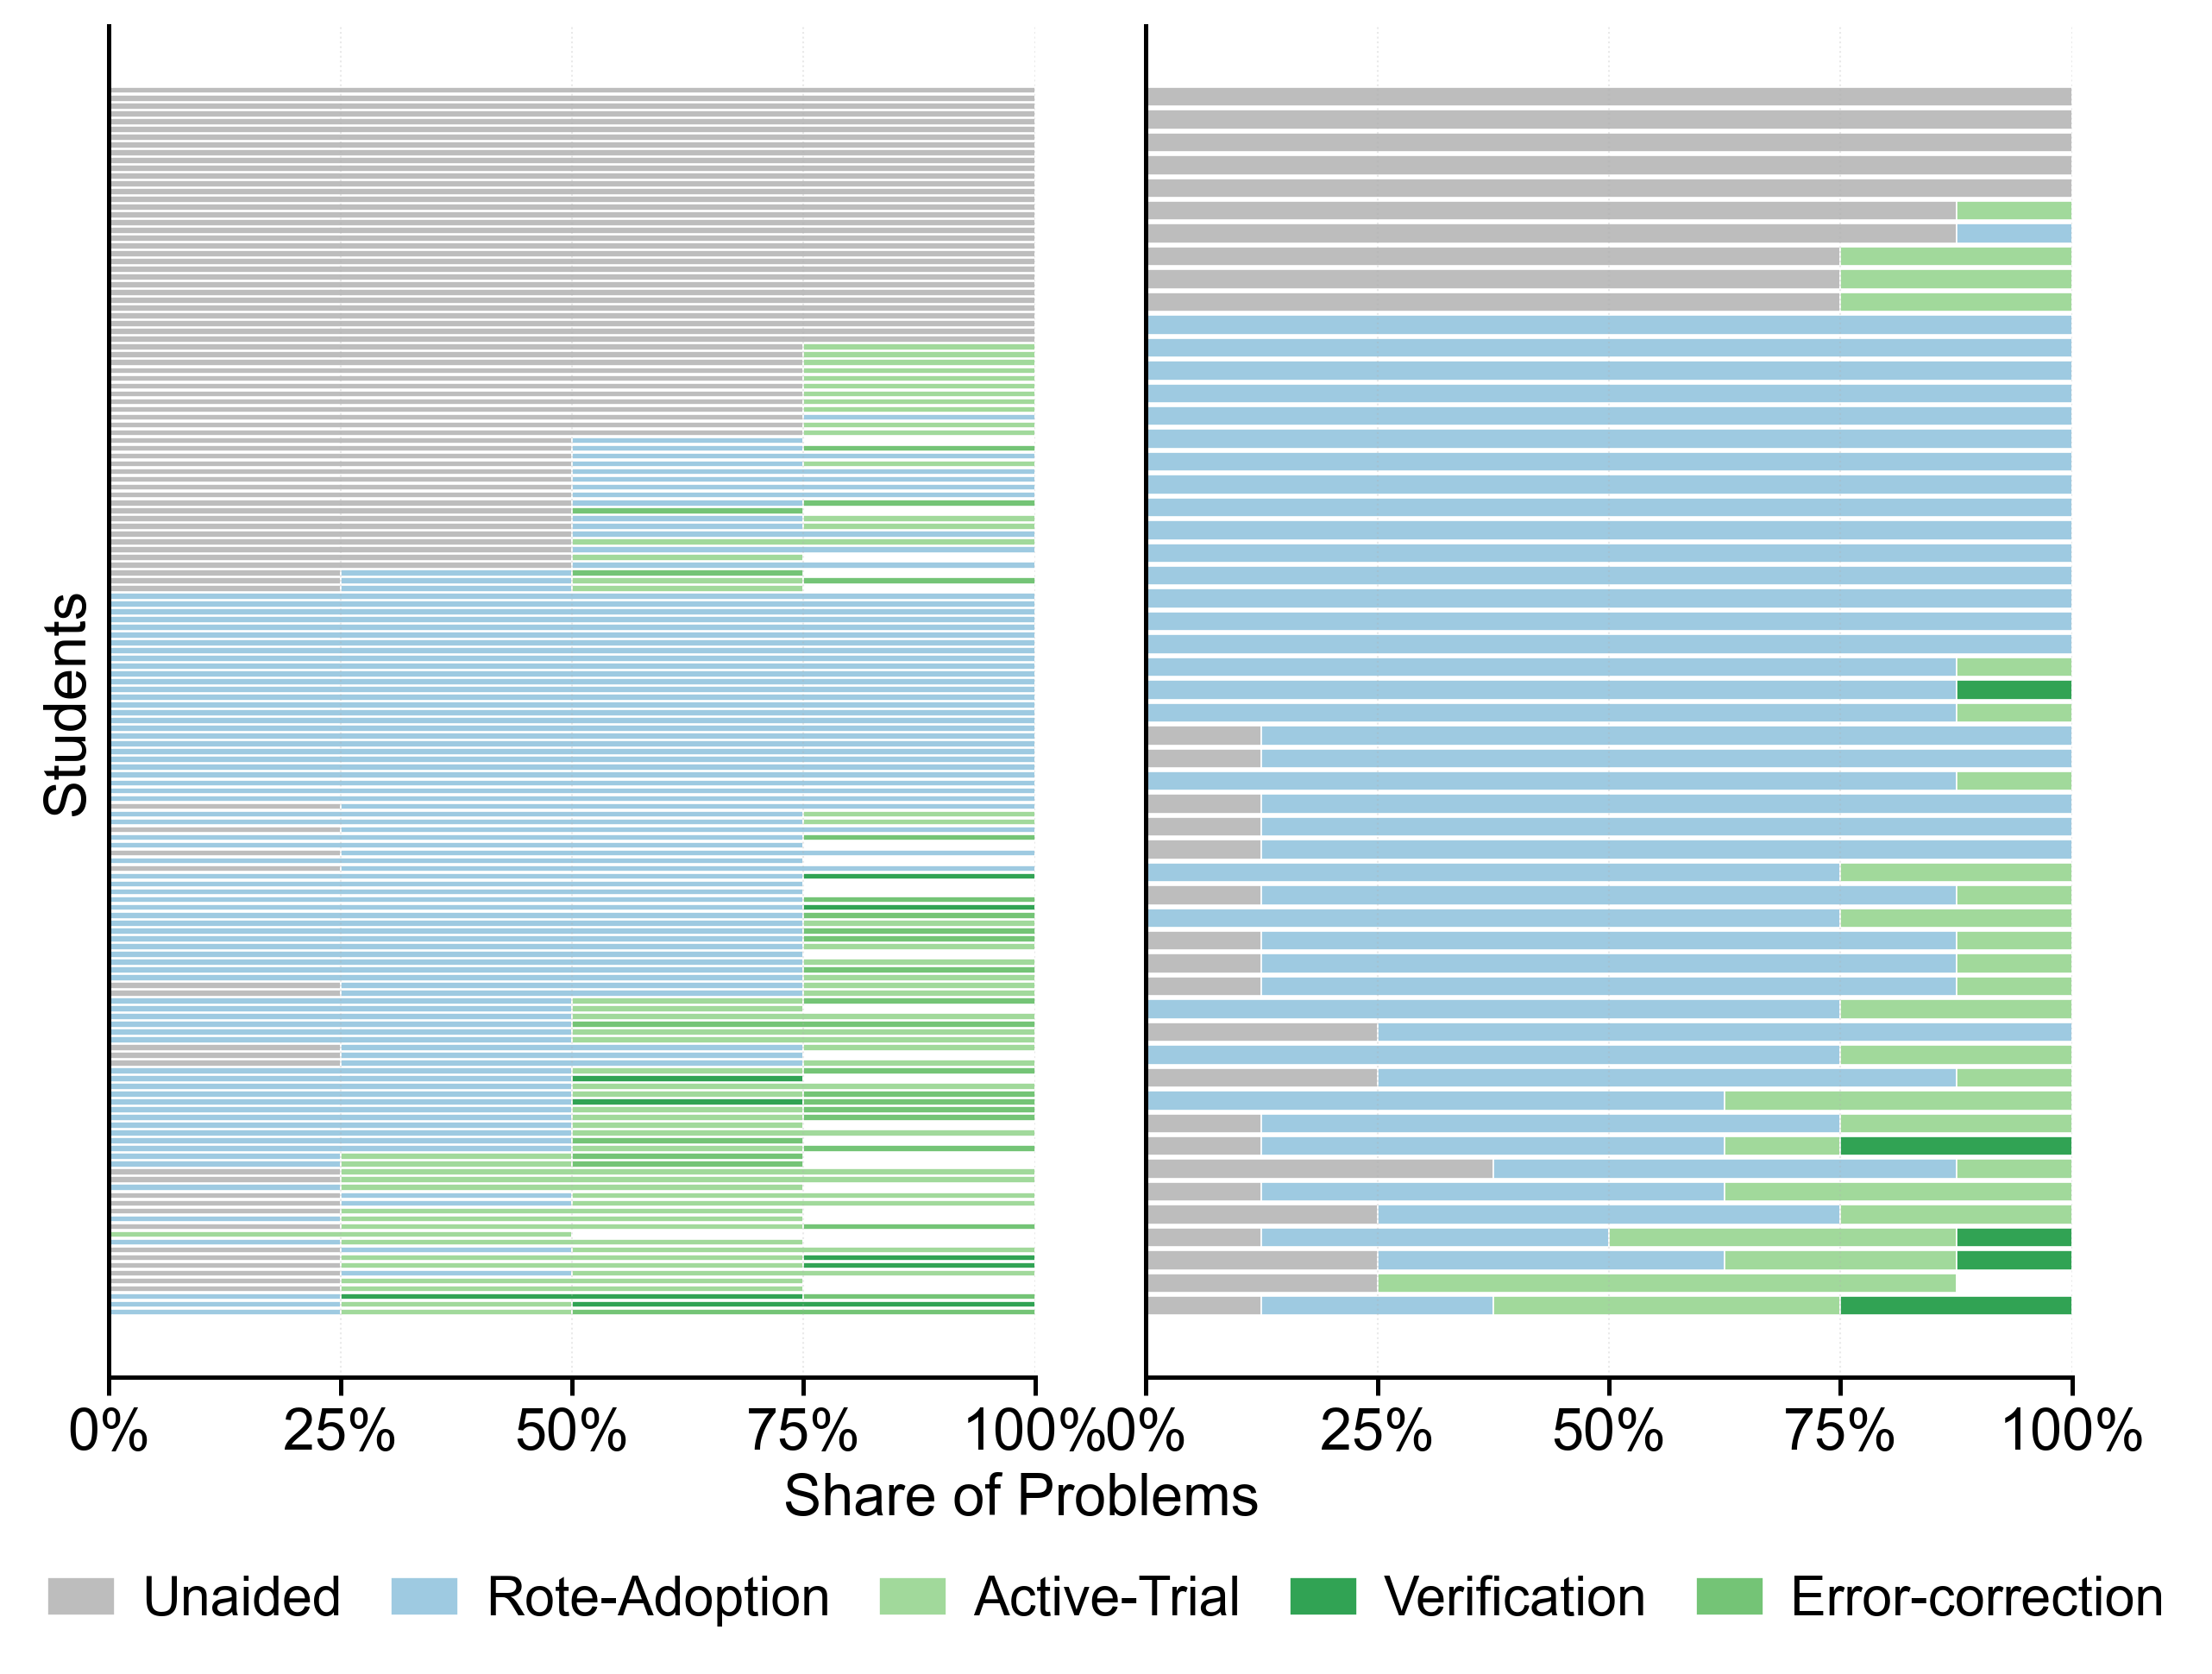


Control vs Experiment (behavior groups) hypothesis tests (raw p-values):
  Control: n=79 mean=5.089 median=3.812
  Unaided: n=33 mean=4.920 median=4.375
  Rote-Adoption: n=47 mean=4.394 median=2.688
  Active-Trial: n=47 mean=5.858 median=5.250
  Error-Correction: n=24 mean=6.526 median=7.125
  Verification: n=7 mean=9.857 median=10.000

  Kruskal–Wallis across groups: H=19.5247, p=0.00153409 (k=6)

  Pairwise Brunner–Munzel vs Control (one-sided where specified):
group	n_ctrl	n_grp	alt	stat	p_raw	p_bh
Unaided	79	33	less	-0.3463	0.634955	0.634955
Rote-Adoption	79	47	less	0.6489	0.258884	0.323605
Active-Trial	79	47	greater	-2.1072	0.0185573	0.0309288
Error-Correction	79	24	greater	-2.1826	0.0170847	0.0309288
Verification	79	7	greater	-8.0089	6.81988e-12	3.40994e-11
Saved figure: a1_math_hw2_control_vs_exp_behavior.pdf


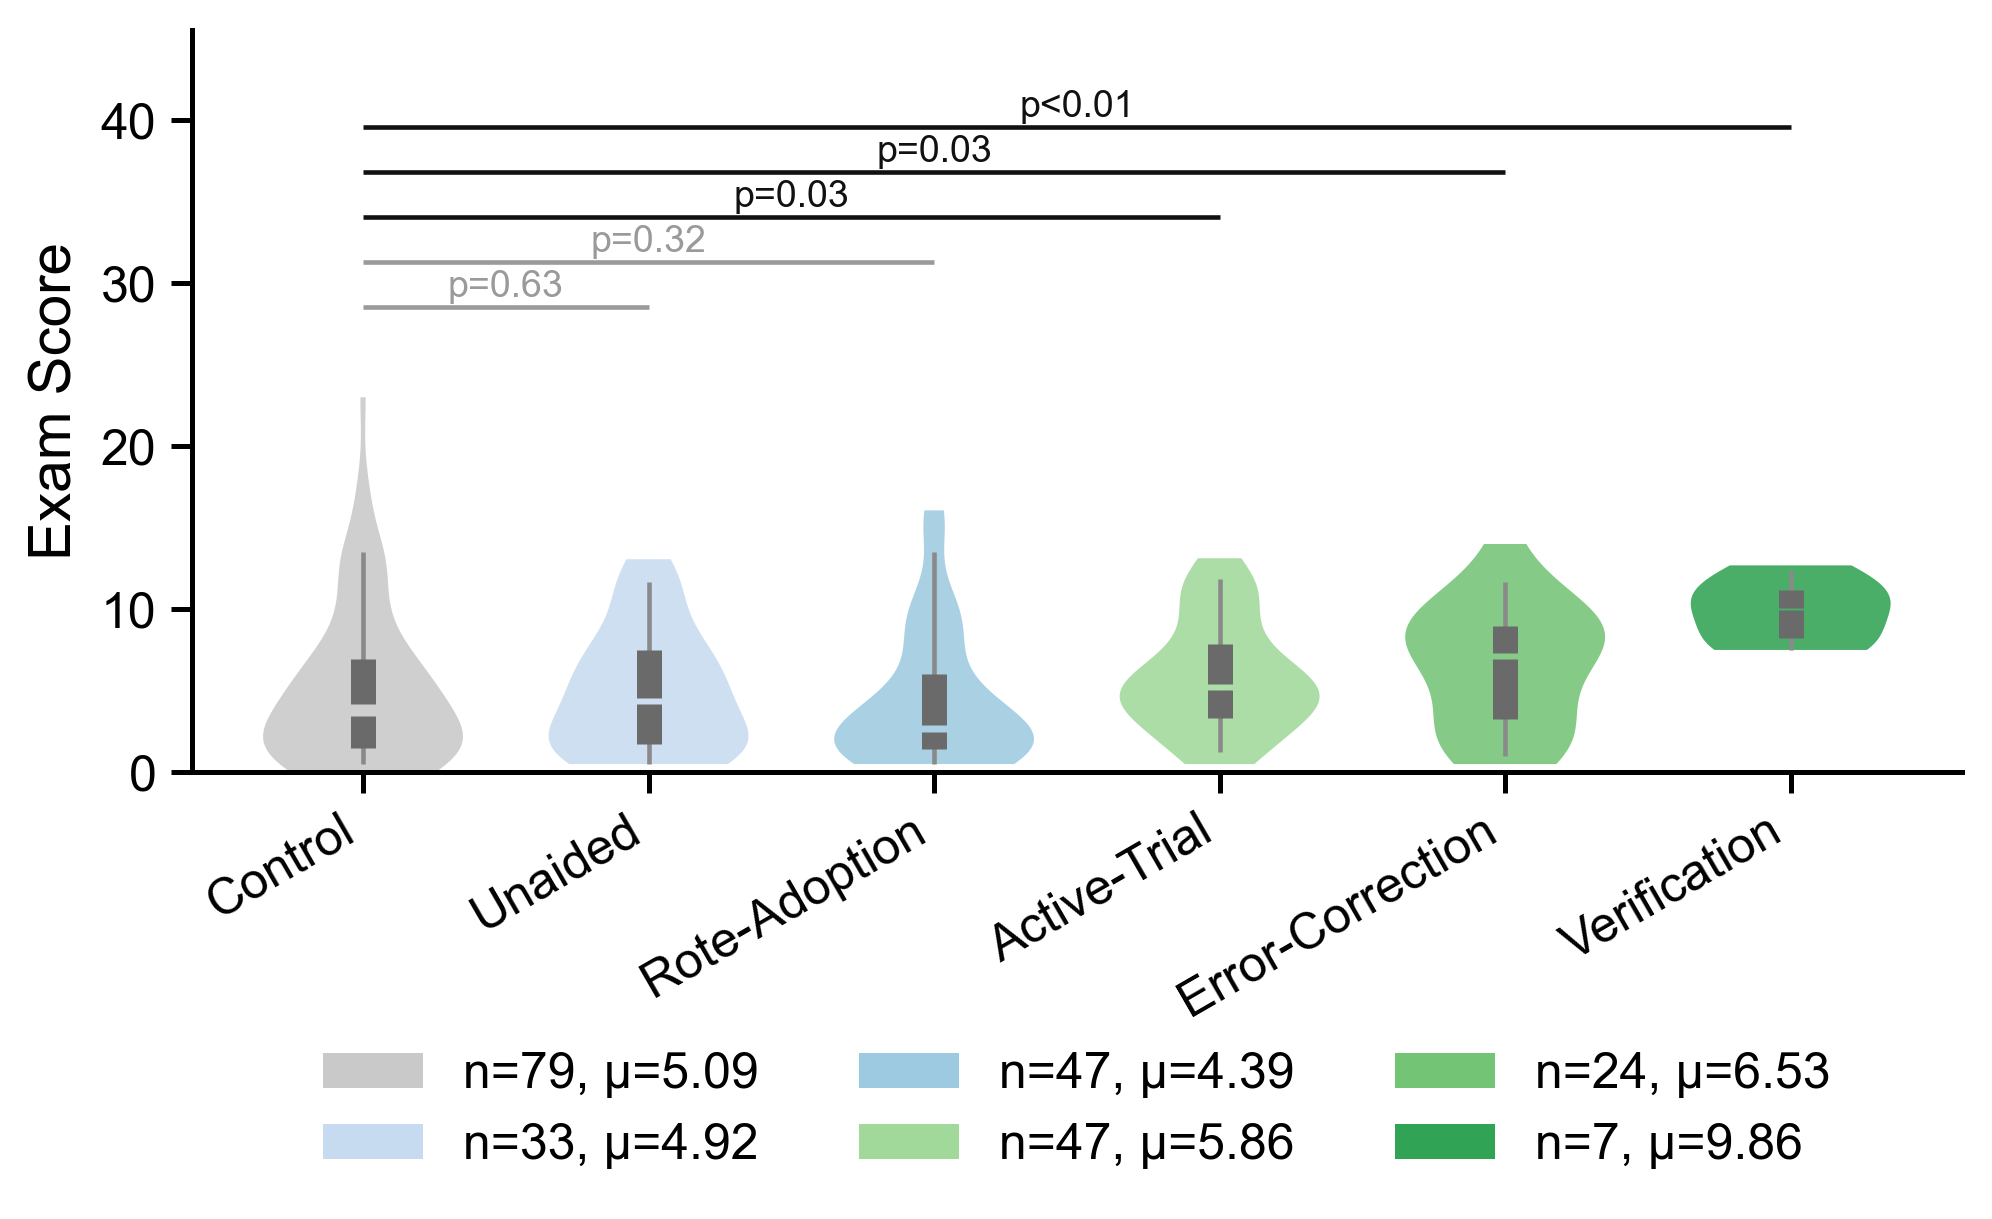

In [9]:
def py_problem_features_for_mix(seq, problem_id, attempted_without_chat):
    # Problem-level features used for the stacked behavior-composition panel.
    return behavior.compute_single_problem_features(
        seq,
        attempted_without_chat=attempted_without_chat,
        nochat_tried_if_attempted=True,
    )


def math_problem_features_for_mix(seq, problem_id, attempted_without_chat):
    # Start with generic math problem features, then add correctness-aware signals.
    pf = behavior.compute_single_problem_features_math(
        seq,
        problem_id=problem_id,
        attempted_without_chat=attempted_without_chat,
        nochat_tried_if_attempted=True,
        pretry_blank_prop_threshold=0.8,
    )

    # Verification: the student challenges an answer that is marked wrong.
    pf["challenge_wrong"] = any(c.ask_type == "challenge" and c.llm_wrong for c in seq)

    # Error-correction: the model was wrong on a blank, the student later has it correct,
    # and the correctness was not already present before the AI response.
    llm_correct, llm_wrong, post_correct, pre_correct = set(), set(), set(), set()
    for c in seq:
        ok, bad = behavior.blanks_by_correct(c.ask_blanks)
        llm_correct.update(ok)
        llm_wrong.update(bad)
        ok, _ = behavior.blanks_by_correct(c.post_blanks)
        post_correct.update(ok)
        ok, _ = behavior.blanks_by_correct(c.pre_blanks)
        pre_correct.update(ok)
    pf["fix_after_wrong"] = bool((llm_wrong - llm_correct) & post_correct & (post_correct - pre_correct))
    return pf

# Draw the student-by-problem behavior composition chart for both courses.
behavior_plots.plot_behavior_heterogeneity_two_panel(
    py_user_problem_chats=py_problem_chats,
    py_user_problem_attempted_without_chat=py_attempted_without_chat,
    py_target_problems=py_target_problems,
    py_problem_features_fn=py_problem_features_for_mix,
    math_user_problem_chats=math_problem_chats,
    math_user_problem_attempted_without_chat=math_attempted_without_chat,
    math_target_problems=math_target_problems,
    math_problem_features_fn=math_problem_features_for_mix,
    out_pdf=FIGURES_DIR / "a1_behavior_heterogeneity_twin_python_game_theory.pdf",
    show=SHOW_FIGURES,
)

# Build the no-assistant comparison distribution for Game Theory.
control_hw2_math = [
    behavior.safe_float(record.get("HW2"))
    for uid, record in math_scores.items()
    if isinstance(record, dict)
    and record.get("group") == "Control"
    and uid not in excluded_users
]
control_hw2_math = [x for x in control_hw2_math if x is not None]

# Use the mapped Game Theory dataframe so the score comparison matches the summary labels.
math_scores_by_behavior = {
    label: math_profile_df.loc[math_profile_df["category"] == label, "HW2"].dropna().astype(float).tolist()
    for label in behavior.MATH_BEHAVIOR_ORDER
}
math_scores_by_behavior = {k: v for k, v in math_scores_by_behavior.items() if v}

stats_tests.print_control_vs_exp_tests(
    control_hw2=control_hw2_math,
    exp_hw2_by_behavior=math_scores_by_behavior,
    direction_by_group={
        "Unaided": "less",
        "Rote-Adoption": "less",
        "Active-Trial": "greater",
        "Error-Correction": "greater",
        "Verification": "greater",
    },
)

behavior_plots.plot_control_vs_exp_behaviors_hw2(
    control_hw2=control_hw2_math,
    exp_hw2_by_behavior=math_scores_by_behavior,
    exp_label_to_color={
        "Active-Trial": "#a1d99b",
        "Error-Correction": "#74c476",
        "Verification": "#31a354",
    },
    out_pdf=FIGURES_DIR / "a1_math_hw2_control_vs_exp_behavior.pdf",
    show=SHOW_FIGURES,
    direction_by_group={
        "Unaided": "less",
        "Rote-Adoption": "less",
        "Active-Trial": "greater",
        "Error-Correction": "greater",
        "Verification": "greater",
    },
)


## Outputs

The notebook writes three files: the two-course behavior composition chart and one behavior-outcome comparison for each course.
